# Exploring the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
sns.set_color_codes('pastel')

In [2]:
ds = pd.read_csv('dataset.csv')


In [3]:
ds.columns


Index(['subject_id', 'stay_id', 'study_id', 'dicom_id', 'icu_intime', 'gender',
       'age', 'hospital_expire_flag', 'glucose_min', 'glucose_max',
       'glucose_mean', 'lactate_min', 'lactate_max', 'lactate_mean',
       'creatinine_min', 'creatinine_max', 'creatinine_mean',
       'heart_rate_mean', 'heart_rate_min', 'heart_rate_max',
       'blood_pressure_mean', 'blood_pressure_min', 'blood_pressure_max',
       'resp_rate_mean', 'resp_rate_min', 'resp_rate_max', 'temp_f_mean',
       'temp_f_min', 'temp_f_max', 'spO2_mean', 'spO2_min', 'spO2_max'],
      dtype='str')

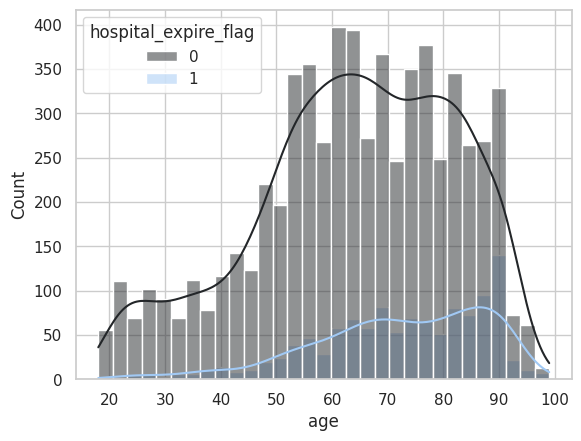

In [4]:
# The label
sns.histplot(
  data=ds,
  x='age',
  palette='dark:b',
  hue='hospital_expire_flag',
  kde=True
);


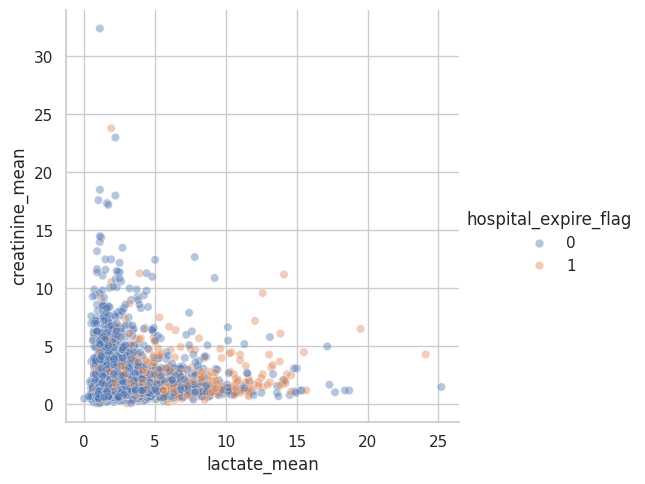

In [5]:
sns.relplot(
  data=ds,
  x='lactate_mean',
  y='creatinine_mean',
  hue='hospital_expire_flag',
  alpha=0.4
);

In [6]:
corr_features = ds[['gender', 'glucose_min', 'glucose_max',
       'glucose_mean', 'lactate_min', 'lactate_max', 'lactate_mean',
       'creatinine_min', 'creatinine_max', 'creatinine_mean',
       'heart_rate_mean', 'heart_rate_min', 'heart_rate_max',
       'blood_pressure_mean', 'blood_pressure_min', 'blood_pressure_max',
       'resp_rate_mean', 'resp_rate_min', 'resp_rate_max', 'temp_f_mean',
       'temp_f_min', 'temp_f_max', 'spO2_mean', 'spO2_min', 'spO2_max']]
corr_features['gender'] = corr_features['gender'].map({'M': 0, 'F': 1})

<Axes: >

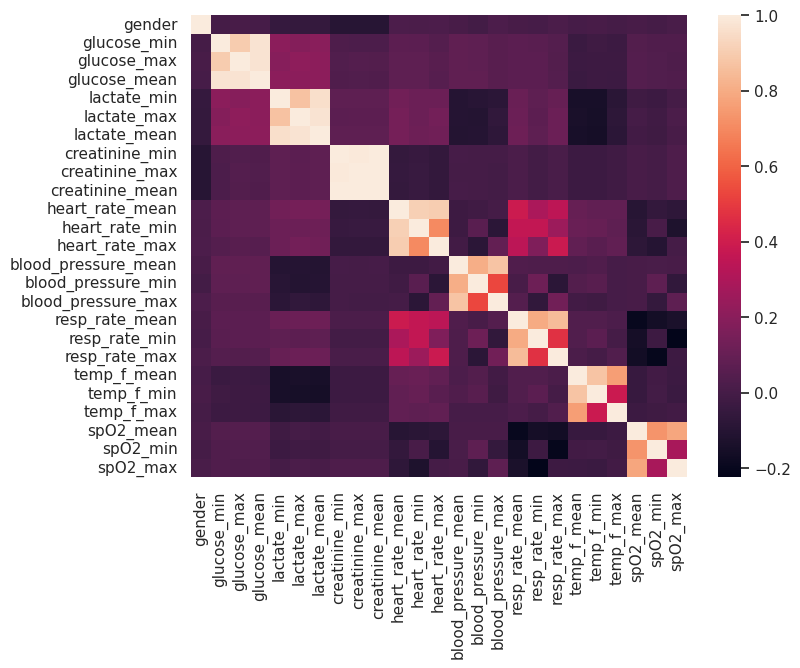

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=corr_features.corr())

In [14]:
train_ds = pd.read_csv('ds_train.csv')
val_ds = pd.read_csv('ds_val.csv')
test_ds = pd.read_csv('ds_test.csv')

In [15]:
train_ds['purpose'] = 'training'
val_ds['purpose'] = 'validation'
test_ds['purpose'] = 'test'
combined_ds = pd.concat([train_ds, val_ds, test_ds])

In [28]:
def plot_continuous_feature(feat: str):
	sns.kdeplot(
		data=combined_ds, 
		x=feat, 
		hue='purpose', 
		common_norm=False, 
		fill=False, 
		alpha=0.3,
		palette={'training': 'blue', 'validation': 'orange', 'test': 'green'}
	)